|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 4:</h2>|<h1>The Scheduler<h1>|
|<h2>Section:</h2>|<h1>Admission and preemption<h1>|
|<h2>Lecture:</h2>|<h1><b>Swap or throw it away: the inequality, and why it is not the decision<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Swap, or throw it away?

You have decided to preempt a sequence. Its K and V are sitting in blocks
you need. Two options:

- **swap**: copy the blocks to CPU memory, and copy them back later
- **recompute**: free the blocks, and prefill the sequence again when it
  resumes

The usual advice is that recompute wins. Measure it rather than believing it.

In [2]:
# how fast is the road to CPU memory?
num_values = 256*1024*1024 // 2
on_gpu = torch.empty(num_values, dtype=torch.bfloat16, device='cuda')
on_cpu = torch.empty(num_values, dtype=torch.bfloat16, pin_memory=True)

to_cpu_ms = cudalib.bench_ms(lambda: on_cpu.copy_(on_gpu), iters=10, warmup=3, best_of=2)
to_gpu_ms = cudalib.bench_ms(lambda: on_gpu.copy_(on_cpu), iters=10, warmup=3, best_of=2)
pcie_gbs = (num_values*2)/(to_cpu_ms*1e-3)/1e9
hbm_gbs = cudalib.peak_bandwidth(fresh=True)

print(f'GPU -> CPU: {pcie_gbs:5.1f} GB/s')
print(f'CPU -> GPU: {(num_values*2)/(to_gpu_ms*1e-3)/1e9:5.1f} GB/s')
print(f'HBM:        {hbm_gbs:5.0f} GB/s   ({hbm_gbs/pcie_gbs:.0f}x faster than the road out)')

del on_gpu, on_cpu
torch.cuda.empty_cache()

GPU -> CPU:  13.2 GB/s
CPU -> GPU:  12.4 GB/s
HBM:          295 GB/s   (22x faster than the road out)


### And how fast is prefill?

In [3]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()
# 2 for K and V, per layer, per kv head, per element of head_dim, bf16.
config = model.config
KV_PER_TOKEN = 2 * config.num_hidden_layers * config.num_key_value_heads * config.head_dim * 2

@torch.inference_mode()
def prefill_ms(num_tokens):
  token_ids = torch.randint(0, 1000, (1,num_tokens), device='cuda')
  return cudalib.bench_ms(lambda: model(token_ids, use_cache=True, logits_to_keep=1),
                          iters=8, warmup=3, best_of=2)

token_counts = [256, 512, 1024, 2048]
print(f"{'tokens':>7} {'recompute':>11} {'swap out+in':>13} {'winner':>11}")
rows = []
for num_tokens in token_counts:
  recompute_ms = prefill_ms(num_tokens)
  swap_ms = 2 * (num_tokens*KV_PER_TOKEN) / (pcie_gbs*1e9) * 1000
  rows.append((num_tokens, recompute_ms, swap_ms))
  print(f'{num_tokens:>7} {recompute_ms:>10.1f}ms {swap_ms:>12.1f}ms {("swap" if swap_ms<recompute_ms else "recompute"):>11}')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 7640.48it/s]

 tokens   recompute   swap out+in      winner


    256       12.3ms          4.5ms        swap


    512       22.1ms          8.9ms        swap


   1024       47.9ms         17.8ms        swap


   2048      102.5ms         35.6ms        swap


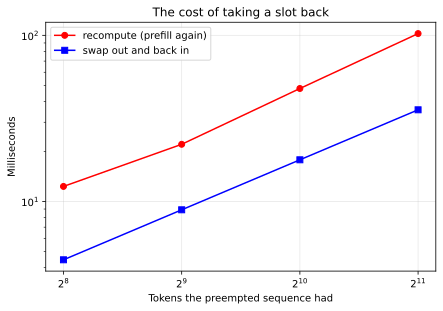

In [4]:
results = np.array(rows)
plt.figure(figsize=(7,4.5))
plt.plot(results[:,0], results[:,1], 'ro-', label='recompute (prefill again)')
plt.plot(results[:,0], results[:,2], 'bs-', label='swap out and back in')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Tokens the preempted sequence had')
plt.ylabel('Milliseconds')
plt.title('The cost of taking a slot back')
plt.legend()
plt.grid(alpha=.3)
plt.show()

### On this machine, swap wins. So why does vLLM prefer recompute?

Both lines are straight and parallel, because the number of tokens controls
both costs. One inequality tells you which cost is lower:

$$\text{recompute wins when}\quad
  \frac{\text{prefill ms}}{\text{token}} < \frac{2 \times \text{KV bytes/token}}{\text{PCIe}}$$

Put your own model into it, because both sides move:

In [5]:
# Both costs are (bytes or FLOPs) divided by a rate, so put them over each
# other and the seconds cancel:
#
#   recompute   2 P / C        P       I
#   --------- = ---------  =  ----  x  ---
#     swap      2 KV / I       KV       C
#
#   P  = parameters          KV = KV cache bytes per token
#   C  = FLOP/s              I  = interconnect bytes/s
#
# The left factor is the MODEL: parameters carried per byte of KV per token.
# The right factor is the MACHINE: interconnect per unit of compute.
# Above 1, swapping is the cheaper of the two.

matrix = torch.randn(4096, 4096, device='cuda', dtype=torch.bfloat16)
C_MEASURED = 2*4096**3 / (cudalib.bench_ms(lambda: matrix@matrix, iters=50, warmup=30)*1e-3)
del matrix
torch.cuda.empty_cache()

I_MEASURED = pcie_gbs * 1e9
print(f'measured: {C_MEASURED/1e12:.0f} TFLOP/s, {I_MEASURED/1e9:.1f} GB/s interconnect')
print(f'I/C = {I_MEASURED/C_MEASURED:.2e} bytes per FLOP/s\n')

def recompute_over_swap(params, kv_per_token, flops, interconnect):
  return (params / kv_per_token) * (interconnect / flops)

MODELS = {
  #                  params, layers, kv_heads, head_dim
  'Qwen3-0.6B':     (0.6e9,  28,     8,        128),
  'Llama-3-8B':     (8.0e9,  32,     8,        128),
  'Llama-3-70B':    (70e9,   80,     8,        128),
  'a 7B with MHA':  (7.0e9,  32,     32,       128),   # no GQA
}

print(f"{'model':>16} {'P/KV':>10} {'ratio':>8}  cheaper")
for name, (params, layers, kv_heads, head_dim) in MODELS.items():
  kv_bytes = 2 * layers * kv_heads * head_dim * 2
  ratio = recompute_over_swap(params, kv_bytes, C_MEASURED, I_MEASURED)
  print(f'{name:>16} {params/kv_bytes:>10,.0f} {ratio:>8.2f}  {"swap" if ratio > 1 else "recompute"}')

measured: 36 TFLOP/s, 13.2 GB/s interconnect
I/C = 3.70e-04 bytes per FLOP/s

           model       P/KV    ratio  cheaper
      Qwen3-0.6B      5,232     1.94  swap
      Llama-3-8B     61,035    22.61  swap
     Llama-3-70B    213,623    79.14  swap
   a 7B with MHA     13,351     4.95  swap


### The model decides, and it mostly decides against recompute

Read the `P/KV` column. Grouped-query attention made the KV cache smaller and
kept the parameter count the same. So a modern model carries tens of thousands
of parameters for each byte of cache for each token. A recompute repeats all of
that arithmetic. A swap moves a small number of bytes.

The last row is the same 7B model without GQA. It has four times the KV cache
and four times fewer parameters for each byte, and the ratio moves by four.
GQA did more than save memory. It changed which preemption strategy is cheaper.

The machine enters only as `I / C`, which is interconnect bytes for each FLOP
for each second. A node with NVLink has approximately one hundred times more of
it than a node on PCIe. That moves every row at the same time.

### So why do real engines still make recompute the default?

This ratio is not the decision. It compares two totals. It ignores *when* the
engine pays each one:

- **A swap-in sits on the critical path.** The sequence waits for its bytes.
  You can cut a recompute into chunks and co-schedule them. Stage 11 does this.
- **Many users share the interconnect.** This measurement had the bus alone. A
  real node also moves weights, activations and the data of other tenants.
- **The prefix can still be in the cache.** Stage 09 makes a recompute start
  from a part of the prompt. The formula does not know this.
- **A swap needs pinned host memory in advance.** You could give that memory to
  the KV pool instead.

The honest statement is not "recompute is faster". Recompute is
**schedulable**, and a ratio of two totals cannot show that.

### The formula and the stopwatch disagree. Take that seriously.

For the small model, `2P/C` says that recompute is cheap. The direct
measurement said that it is not. The formula is correct. One of its
assumptions is wrong.

`2P/C` assumes that prefill runs at **peak** compute. A 0.6B model at a few
hundred tokens does not do this. It is too small to fill the tensor cores, so
it reads weights like a decode step. Divide the prediction by the measurement
to get the efficiency. Put that efficiency back into the formula, and the
verdict agrees with the stopwatch.

A big model does reach a large fraction of peak on prefill. So the formula
needs no correction for it, and you can trust the `Llama-3-70B` row without a
measurement.

The ratio has the correct shape, and it needs one calibration number from your
own machine. This is the usual situation. It is worth more than the formula
alone and more than the measurement alone.

The formula tells you which way the answer moves when the model or the node
changes. The measurement tells you where you stand now.

In [6]:
# The formula said one thing about Qwen3-0.6B and the measurement above said
# another. Find out which assumption broke.
qwen_params = sum(weight.numel() for weight in model.parameters())
predicted_ms_per_token = 1000 * 2*qwen_params / C_MEASURED
# the slope of the measured prefill times
measured_ms_per_token = (rows[-1][1]-rows[0][1]) / (token_counts[-1]-token_counts[0])

efficiency = predicted_ms_per_token / measured_ms_per_token
print(f'prefill at peak FLOPs would be {predicted_ms_per_token:.4f} ms/token')
print(f'you measured                  {measured_ms_per_token:.4f} ms/token')
print(f'-> prefill runs at {100*efficiency:.0f}% of peak compute on this model\n')

ratio_at_peak = recompute_over_swap(qwen_params, KV_PER_TOKEN, C_MEASURED, I_MEASURED)
ratio_measured = recompute_over_swap(qwen_params, KV_PER_TOKEN, C_MEASURED*efficiency, I_MEASURED)
print(f'ratio assuming peak compute: {ratio_at_peak:.2f}  -> {"swap" if ratio_at_peak>1 else "recompute"}')
print(f'ratio using measured prefill:{ratio_measured:.2f}  -> {"swap" if ratio_measured>1 else "recompute"}')

prefill at peak FLOPs would be 0.0335 ms/token
you measured                  0.0503 ms/token
-> prefill runs at 67% of peak compute on this model

ratio assuming peak compute: 1.93  -> swap
ratio using measured prefill:2.89  -> swap
